<a href="https://colab.research.google.com/github/JU4NP41306/JOBLIB/blob/main/Clasificacion_de_Vinos_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Construcción del modelo de clasificación de vinos

**Objetivo:** entrenar y evaluar un modelo SVM con el conjunto *Wine* de scikit-learn y guardar el Pipeline como `modelo_wine.pkl`.

**Fuente:** [Wine recognition dataset, scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset). Cada fila representa una muestra de vino analizada mediante propiedades químicas. Se utilizan cuatro variables numéricas: `alcohol`, `malic_acid`, `color_intensity` y `proline`. La variable objetivo es `tipo_vino`. **Cabernet, Merlot y Pinot Noir son etiquetas didácticas**, no variedades reales identificadas por el conjunto original.

**Métrica principal:** F1 macro, ya que da el mismo peso a las tres clases y combina precisión y recall. También se reportan accuracy, precision y recall. Ejecuta todas las celdas en orden en Colab; la última permite descargar el archivo entrenado.

## 1. Importar librerías y cargar Wine

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, ConfusionMatrixDisplay, confusion_matrix

wine = load_wine(as_frame=True)
df = wine.data.copy()
df["target"] = wine.target
print("Primeros registros del dataset original:")
print(df.head().to_string(index=False))

Primeros registros del dataset original:
 alcohol  malic_acid  ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  hue  od280/od315_of_diluted_wines  proline  target
   14.23        1.71 2.43               15.6      127.0           2.80        3.06                  0.28             2.29             5.64 1.04                          3.92   1065.0       0
   13.20        1.78 2.14               11.2      100.0           2.65        2.76                  0.26             1.28             4.38 1.05                          3.40   1050.0       0
   13.16        2.36 2.67               18.6      101.0           2.80        3.24                  0.30             2.81             5.68 1.03                          3.17   1185.0       0
   14.37        1.95 2.50               16.8      113.0           3.85        3.49                  0.24             2.18             7.80 0.86                          3.45   1480.0       0
   1

## 2. Asignar etiquetas didácticas

In [4]:
etiquetas = {0: "Cabernet", 1: "Merlot", 2: "Pinot Noir"}
orden_clases = [etiquetas[i] for i in range(3)]
df["tipo_vino"] = df["target"].map(etiquetas)
print(df[["target", "tipo_vino"]].head(10).to_string(index=False))

 target tipo_vino
      0  Cabernet
      0  Cabernet
      0  Cabernet
      0  Cabernet
      0  Cabernet
      0  Cabernet
      0  Cabernet
      0  Cabernet
      0  Cabernet
      0  Cabernet


## 3. Explorar los datos

In [5]:
print("Dimensiones (filas, columnas):", df.shape)
print("Variables originales:", wine.data.shape[1])
print("\nTipos de datos:")
print(df.dtypes.to_string())
print("\nValores faltantes por columna:")
print(df.isna().sum().to_string())
print("\nDuplicados completos:", df.duplicated().sum())
print("\nEstadísticas de las cuatro variables seleccionadas:")
print(df[["alcohol", "malic_acid", "color_intensity", "proline"]].describe().round(2).to_string())
print("\nRegistros por tipo de vino:")
print(df["tipo_vino"].value_counts().reindex(orden_clases).to_string())

Dimensiones (filas, columnas): (178, 15)
Variables originales: 13

Tipos de datos:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
tipo_vino                        object

Valores faltantes por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyani

**Análisis:** no hay valores faltantes. Las clases tienen tamaños diferentes y las variables muestran escalas distintas; por eso se estratifica la división y se escala dentro del Pipeline.

## 4. Seleccionar X e y y separar entrenamiento y prueba

In [6]:
columnas = ["alcohol", "malic_acid", "color_intensity", "proline"]
X = df[columnas].copy()
y = df["tipo_vino"].copy()
print("X:", X.shape, "| y:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Entrenamiento:", X_train.shape, "| prueba:", X_test.shape)
print("Clases en entrenamiento:", y_train.value_counts().reindex(orden_clases).to_dict())
print("Clases en prueba:", y_test.value_counts().reindex(orden_clases).to_dict())

X: (178, 4) | y: (178,)
Entrenamiento: (142, 4) | prueba: (36, 4)
Clases en entrenamiento: {'Cabernet': 47, 'Merlot': 57, 'Pinot Noir': 38}
Clases en prueba: {'Cabernet': 12, 'Merlot': 14, 'Pinot Noir': 10}


El conjunto de prueba permite evaluar muestras que el modelo no vio durante el entrenamiento. La estratificación conserva aproximadamente la proporción de cada clase en ambos conjuntos.

## 5. Crear y entrenar el Pipeline

In [7]:
modelo = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="linear"))])
modelo.fit(X_train, y_train)
print(modelo)
print("Clases aprendidas:", list(modelo.classes_))

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(kernel='linear'))])
Clases aprendidas: ['Cabernet', 'Merlot', 'Pinot Noir']


El Pipeline ajusta el escalador solo con los datos de entrenamiento. Al predecir, aplica la misma transformación automáticamente y evita filtrar información del conjunto de prueba.

## 6. Predecir y evaluar

In [8]:
y_pred = modelo.predict(X_test)
comparacion = pd.DataFrame({"Real": y_test.to_numpy(), "Predicho": y_pred}, index=X_test.index)
print("Comparación real vs. predicho:")
print(comparacion.to_string(index=False))
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=orden_clases, average="macro", zero_division=0)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision macro: {precision:.4f}")
print(f"Recall macro: {recall:.4f}")
print(f"F1 macro: {f1:.4f}")
print("\nResultados por clase:")
print(classification_report(y_test, y_pred, labels=orden_clases, zero_division=0))

Comparación real vs. predicho:
      Real   Predicho
  Cabernet   Cabernet
Pinot Noir     Merlot
  Cabernet   Cabernet
    Merlot Pinot Noir
    Merlot     Merlot
  Cabernet   Cabernet
  Cabernet   Cabernet
    Merlot     Merlot
    Merlot     Merlot
Pinot Noir Pinot Noir
    Merlot     Merlot
Pinot Noir Pinot Noir
  Cabernet   Cabernet
Pinot Noir     Merlot
  Cabernet   Cabernet
    Merlot     Merlot
    Merlot     Merlot
  Cabernet   Cabernet
    Merlot     Merlot
  Cabernet   Cabernet
    Merlot     Merlot
    Merlot     Merlot
  Cabernet   Cabernet
  Cabernet   Cabernet
    Merlot     Merlot
    Merlot     Merlot
  Cabernet   Cabernet
Pinot Noir Pinot Noir
    Merlot     Merlot
Pinot Noir Pinot Noir
  Cabernet   Cabernet
Pinot Noir Pinot Noir
    Merlot     Merlot
Pinot Noir Pinot Noir
Pinot Noir Pinot Noir
Pinot Noir Pinot Noir

Accuracy: 0.9167
Precision macro: 0.9185
Recall macro: 0.9095
F1 macro: 0.9129

Resultados por clase:
              precision    recall  f1-score   suppor

La tabla por clase permite ver si el modelo falla más en algún grupo; la métrica global por sí sola podría ocultar ese detalle.

## 7. Matriz de confusión

Aciertos: 33
Errores: 3


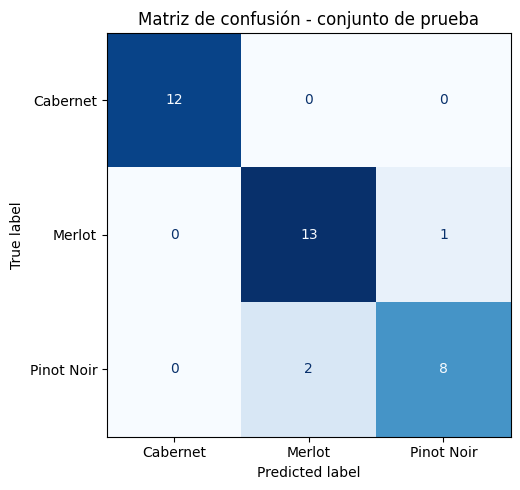

In [9]:
matriz = confusion_matrix(y_test, y_pred, labels=orden_clases)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=orden_clases).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de confusión - conjunto de prueba")
plt.tight_layout()
print("Aciertos:", int(matriz.trace()))
print("Errores:", int(matriz.sum() - matriz.trace()))

La diagonal contiene las predicciones correctas; las celdas fuera de ella muestran qué pares de clases se confundieron.

## 8. Predecir un vino nuevo

In [10]:
vino_nuevo = pd.DataFrame([[13.5, 1.8, 5.2, 1000]], columns=columnas)
print("Datos del vino nuevo:")
print(vino_nuevo.to_string(index=False))
prediccion_antes = modelo.predict(vino_nuevo)[0]
print("Etiqueta didáctica predicha:", prediccion_antes)

Datos del vino nuevo:
 alcohol  malic_acid  color_intensity  proline
    13.5         1.8              5.2     1000
Etiqueta didáctica predicha: Cabernet


## 9. Guardar y recuperar el modelo

In [11]:
ruta = Path("modelo_wine.pkl")
joblib.dump(modelo, ruta)
print("Archivo generado:", ruta.resolve())
print("Existe:", ruta.is_file(), "| tamaño:", ruta.stat().st_size, "bytes")
modelo_recuperado = joblib.load(ruta)
prediccion_despues = modelo_recuperado.predict(vino_nuevo)[0]
print("Antes de guardar:", prediccion_antes)
print("Después de cargar:", prediccion_despues)
print("Coinciden:", prediccion_antes == prediccion_despues)

Archivo generado: /content/modelo_wine.pkl
Existe: True | tamaño: 4709 bytes
Antes de guardar: Cabernet
Después de cargar: Cabernet
Coinciden: True


**Reflexión final:** entrenar significa aprender los parámetros del escalador y del clasificador a partir de ejemplos. Utilizar un modelo guardado significa aplicar esos parámetros a nuevos datos sin volver a entrenar. Flujo: datos → preparación → Pipeline → entrenamiento → evaluación → Joblib → `modelo_wine.pkl`.

En **Google Colab**, ejecuta la celda siguiente si quieres descargar el archivo generado. Se omite automáticamente fuera de Colab.

In [12]:
try:
    from google.colab import files
except ImportError:
    print("Descarga disponible al ejecutar esta celda en Google Colab.")
else:
    files.download("modelo_wine.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>